# Taller 1

**Fecha de entrega:** Miércoles 6 de agosto

Se tiene un conjunto de datos de 1500 registros con las siguientes variables:

- edad_cliente (años)
- tiempo_como_cliente_meses
- ingresos_mensuales (dolares)
- visitas_mensuales_sitio_web
- contactos (call-center)
- nivel_educativo (1:primaria, 2:secundaria, 3:tecnico-tecnologico, 4:universitario, 5 posgrado)
- uso_tarjeta_credito (1: Si, 0: No)
- participa_en_promociones (1: Si, 0: No)
- calificacion_satisfaccion (1-5, donde 1 es muy bajo y 5 es excelente)
- descuento_promedio_usado (%)
- ventas_cliente (Ventas promedio al cliente en dolares)


Se espera que el cientifico de datos presente el mejor modelo de regresión posible para predecir las ventas del cliente, con el respectivo informe ejecutivo para el gerente.
Se deben validar todos los supuestos de la regresión y que esta no presente problemas.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [ ]:
df = pd.read_csv('/content/sample_data/dataset_regresion_ventas.csv')
df.head()

,edad_cliente,tiempo_como_cliente_meses,ingresos_mensuales,visitas_mensuales_sitio_web,contactos,nivel_educativo,uso_tarjeta_credito,participa_en_promociones,calificacion_satisfaccion,descuento_promedio_usado,ventas_cliente
0,50,62,3450,6,0,4,0,1,4,0.26,371.17
1,49,7,2580,4,3,4,1,1,3,0.21,329.62
2,42,92,3090,6,1,4,0,1,3,0.29,589.01
3,30,119,3000,12,1,2,1,1,4,0.21,476.49
4,40,108,2840,4,1,1,1,0,5,0.00,460.06


In [ ]:
train= df.sample(frac=0.8, random_state=200)
test= df.drop(train.index)
print(df.shape[0])

1500


In [ ]:
df.head()
df.columns

Index(['edad_cliente', 'tiempo_como_cliente_meses', 'ingresos_mensuales',
       'visitas_mensuales_sitio_web', 'contactos', 'nivel_educativo',
       'uso_tarjeta_credito', 'participa_en_promociones',
       'calificacion_satisfaccion', 'descuento_promedio_usado',
       'ventas_cliente'],
      dtype='object')

In [ ]:
print(train.shape[0])

1200


In [ ]:
train.describe()

,edad_cliente,tiempo_como_cliente_meses,ingresos_mensuales,visitas_mensuales_sitio_web,contactos,nivel_educativo,uso_tarjeta_credito,participa_en_promociones,calificacion_satisfaccion,descuento_promedio_usado,ventas_cliente
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,44.036667,60.193333,3023.808333,4.920833,2.015000,2.534167,0.495000,0.845833,3.315833,0.126525,445.792083
std,15.072314,34.051929,759.003394,2.169905,1.402883,1.120958,0.500183,0.361259,1.267842,0.096338,130.203770
min,18.000000,1.000000,800.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-5.680000
25%,31.000000,31.000000,2490.000000,3.000000,1.000000,2.000000,0.000000,1.000000,2.000000,0.030000,355.292500
50%,44.000000,61.000000,3040.000000,5.000000,2.000000,3.000000,0.000000,1.000000,4.000000,0.120000,443.690000
75%,57.000000,89.000000,3540.000000,6.000000,3.000000,4.000000,1.000000,1.000000,4.000000,0.210000,535.727500
max,69.000000,119.000000,5150.000000,12.000000,8.000000,4.000000,1.000000,1.000000,5.000000,0.300000,833.220000


In [ ]:
Y = df['ventas_cliente']
X = df['tiempo_como_cliente_meses']

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Para usar las variables de la regresión, estas deben ser tipo array
X = np.array(X).reshape(-1, 1)
Y = np.array(Y).reshape(-1, 1)

# Modelo de regresión
modelo = LinearRegression()
modelo.fit(X, Y)

# Ver coeficientes
print("Intercepto (a):", modelo.intercept_)
print("Pendiente (b):", modelo.coef_)

Intercepto (a): [338.79350595]
Pendiente (b): [[1.77253947]]


In [ ]:
b= sum((X-X.mean())*(Y-Y.mean()))/sum((X-X.mean())**2)
b

array([1.77253947])

In [ ]:
a= Y.mean()-b*X.mean()
a

array([338.79350595])

In [ ]:
import statsmodels.api as sm

# Intercepto
X_const = sm.add_constant(X)

# Modelo de regresión
modelo_sm = sm.OLS(Y, X_const).fit()

# Imprimir el resumen del modelo (incluye la ecuación y ANOVA)
print(modelo_sm.summary())

# Obtener y mostrar los residuales
residuales = modelo_sm.resid
print("\nResiduales:")
print(residuales)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     408.1
Date:                Wed, 06 Aug 2025   Prob (F-statistic):           1.86e-80
Time:                        15:10:08   Log-Likelihood:                -9254.7
No. Observations:                1500   AIC:                         1.851e+04
Df Residuals:                    1498   BIC:                         1.852e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        338.7935      6.078     55.739      0.0

# Metricas de desempeño

In [ ]:
y_real= df['ventas_cliente']
y_pred= modelo.predict(X)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# y_real: valores verdaderos
# y_pred: valores predichos por el modelo

r2 = r2_score(y_real, y_pred)
mse = mean_squared_error(y_real, y_pred)
rmse = np.sqrt(mse)  # raíz del MSE
mae = mean_absolute_error(y_real, y_pred)

print("R^2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R^2: 0.21412161206439817
RMSE: 115.68195937514592
MAE: 93.13197445693305


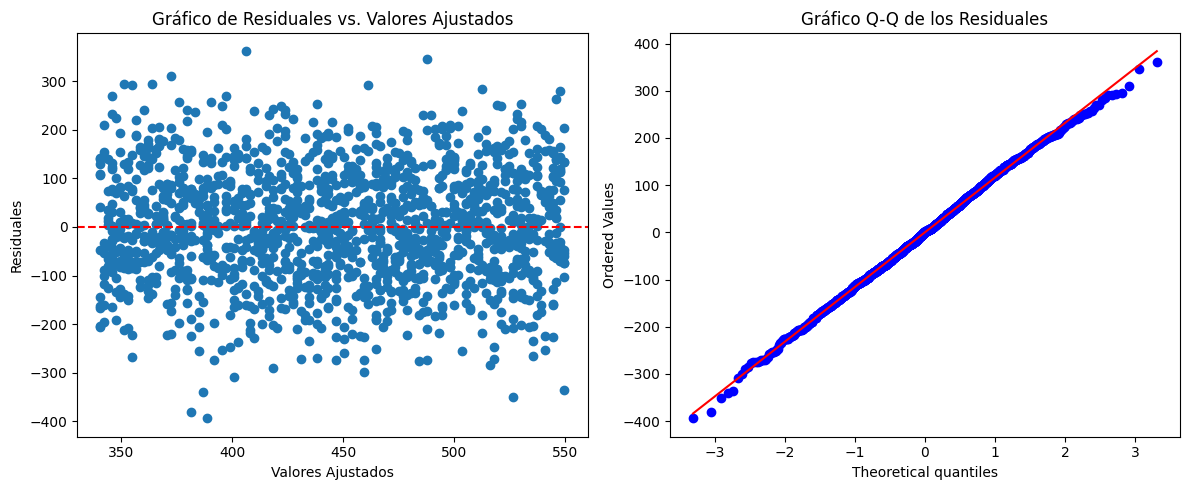

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Gráfico de residuales vs. valores ajustados
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(modelo_sm.fittedvalues, residuales)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuales')
plt.title('Gráfico de Residuales vs. Valores Ajustados')

# Gráfico Q-Q de los residuales
plt.subplot(1, 2, 2)
stats.probplot(residuales, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de los Residuales')

plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm
import pandas as pd


Y_train = train['ventas_cliente']
X_train = train.drop('ventas_cliente', axis=1)


X_train = sm.add_constant(X_train)


multiple_regression_model_train = sm.OLS(Y_train, X_train).fit()


print(multiple_regression_model_train.summary())

                            OLS Regression Results                            
Dep. Variable:         ventas_cliente   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     91.15
Date:                Wed, 06 Aug 2025   Prob (F-statistic):          2.23e-139
Time:                        15:10:09   Log-Likelihood:                -7203.7
No. Observations:                1200   AIC:                         1.443e+04
Df Residuals:                    1189   BIC:                         1.449e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

#ESTO QUEDO BIEN


Variables con significancia estadistica

* Ingresos mensuales
* Descuento promedio (Variable con mas peso 251 dolares en ventas)
* Participa en promociones
* Uso tarjeta de credito

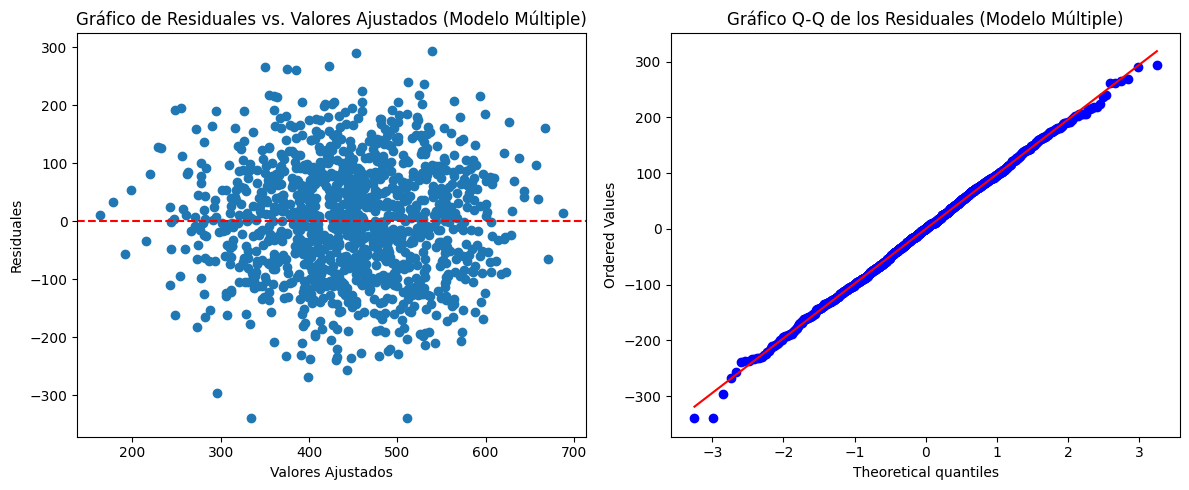

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Get the residuals from the multiple regression model
residuales_multiple = multiple_regression_model_train.resid

# Gráfico de residuales vs. valores ajustados
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(multiple_regression_model_train.fittedvalues, residuales_multiple)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuales')
plt.title('Gráfico de Residuales vs. Valores Ajustados (Modelo Múltiple)')

# Gráfico Q-Q de los residuales
plt.subplot(1, 2, 2)
stats.probplot(residuales_multiple, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de los Residuales (Modelo Múltiple)')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import statsmodels.api as sm

Y_test = test['ventas_cliente']
X_test = test.drop('ventas_cliente', axis=1)

X_test_const = sm.add_constant(X_test)

y_pred_test = multiple_regression_model_train.predict(X_test_const)


r2_11 = r2_score(Y_test, y_pred_test)

print(f'R^2: {r2_11}')

# y_real: valores verdaderos
# y_pred: valores predichos por el modelo

R^2: 0.4280851370611187


# Análisis de resultados

1. Nuestro objetivo es construir un modelo de regresión para predecir las **"ventas_cliente"** basándonos en las siguientes variables:
    * edad_cliente
    * tiempo_como_cliente_meses
    * ingresos_mensuales
    * visitas_mensuales_sitio_web
    * contactos (call-center)
    * nivel_educativo (1:primaria, 2:secundaria, 3:tecnico-tecnologico, 4:universitario, 5 posgrado)
    * uso_tarjeta_credito (1: Si, 0: No)
    * participa_en_promociones (1: Si, 0: No)
    * calificacion_satisfaccion (1-5, donde 1 es muy bajo y 5 es excelente)
    * descuento_promedio_usado (%)

2. Primero realizamos un modelo de regresión simple donde evaluamos las ventas del cliente con base al **"tiempo_como_cliente_meses"**. Observamos un **R-cuadrado de 0.214** en el conjunto completo de datos. Esto indica que solo el 21.4% de la variabilidad en las ventas del cliente es explicada por el tiempo como cliente

3. Procedimos a hacer una **regresión multiple** utilizando todas las variables disponibles en el conjunto de entrenamiento (train). Esto nos mostró un **R-cuadrado de 0.434**. Este modelo explica un mayor porcentaje de la variabilidad en las ventas del cliente en comparación con el modelo simple. Observamos en el resumen del modelo que la mayoría de las variables son estadísticamente significativas (P>|t| < 0.05). Sin embargo, la variable nivel_educativo tiene un valor p de 0.029, que aunque significativo, es mayor que otras variables.
4. Evaluamos el modelo de regresión múltiple en el conjunto de prueba (test) y obtuvimos un **R-cuadrado de 0.428**. Este valor es similar al R-cuadrado del conjunto de entrenamiento, lo que sugiere que el modelo no está sobreajustado

5. Analizamos los gráficos de residuales para el modelo de regresión múltiple. El gráfico de residuales vs. valores ajustados muestra una dispersión de puntos que parece aleatoria alrededor de la línea horizontal en cero, lo que sugiere que el supuesto de **homocedasticidad** (varianza constante de los residuales) podría cumplirse. El gráfico Q-Q de los residuales muestra que los puntos siguen de cerca la línea diagonal, lo que indica que los residuales están aproximadamente **normalmente distribuidos**, aunque hay algunas desviaciones en los extremos.

En conclusion

Según el análisis de regresión múltiple, los siguientes factores tienen un impacto positivo en las ventas de los clientes:

+ Descuento promedio usado: Ofrecer descuentos promedio más altos tiende a aumentar las ventas
+ Participa en promociones: Los clientes que participan en promociones tienden a gastar más
+ Uso tarjeta de credito: Los clientes que utilizan tarjetas de crédito están asociados con mayores ventas
+ Ingresos mensuales: Mayores ingresos se correlacionan con mayores ventas
+ Tiempo como cliente meses: Una mayor antigüedad del cliente está relacionada con un aumento de las ventas
